In [2]:
!unzip "/content/drive/MyDrive/college/sem6/AI&ML/Workshops/Workshop5/Copy of FruitinAmazon.zip"

Archive:  /content/drive/MyDrive/college/sem6/AI&ML/Workshops/Workshop5/Copy of FruitinAmazon.zip
  inflating: FruitinAmazon/test/cupuacu/download (5).jpeg  
  inflating: FruitinAmazon/test/acai/images (2).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (3).jpeg  
  inflating: FruitinAmazon/test/acai/images (16).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (2).jpeg  
  inflating: FruitinAmazon/train/pupunha/images (1).jpeg  
  inflating: FruitinAmazon/test/cupuacu/download (2).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (1).jpeg  
  inflating: FruitinAmazon/train/acai/images (3).jpeg  
  inflating: FruitinAmazon/train/acai/images (4).jpeg  
  inflating: FruitinAmazon/test/graviola/download (1).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (11).jpeg  
  inflating: FruitinAmazon/test/pupunha/download (4).jpeg  
  inflating: FruitinAmazon/train/acai/images (11).jpeg  
  inflating: FruitinAmazon/test/tucuma/download (1).jpeg  
  inflating: FruitinAm

In [3]:
!ls FruitinAmazon/

test  train


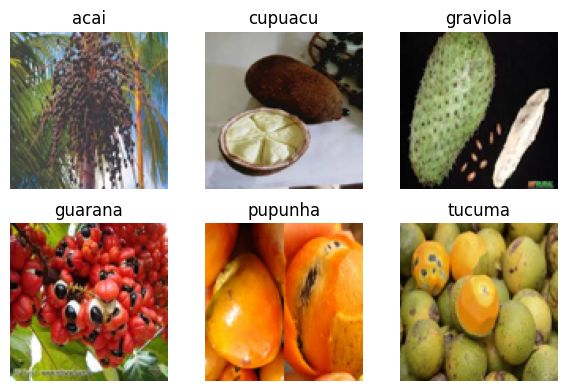

In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt
import random

#Data visualization

train_folder = "FruitinAmazon/train"
class_names = sorted(os.listdir(train_folder))

selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_folder, class_name)
    if os.path.isdir(class_path):
        images_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        if images_in_class:
            random_image_name = random.choice(images_in_class)
            img_path = os.path.join(class_path, random_image_name)
            img = Image.open(img_path).convert("RGB") # Convert to RGB for consistent display
            img = img.resize((100, 100)) # Resize for display
            selected_images.append(img)
            selected_labels.append(class_name)

num_images = len(selected_images)
num_cols = (num_images + 1) // 2 # Max 2 rows
num_rows = 2

plt.figure(figsize=(num_cols * 2, num_rows * 2))
for i in range(num_images):
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(selected_images[i])
    plt.title(selected_labels[i])
    plt.axis('off')
plt.tight_layout()
plt.show()

In [5]:
import sys

#Check for corrupted images


corrupted_images = []

for class_name in os.listdir(train_folder):
    class_path = os.path.join(train_folder, class_name)
    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            try:
                with Image.open(image_path) as img:
                    img.verify() # Verify if it's a valid image
            except (IOError, SyntaxError) as e:
                print(f"Removed corrupted image: {image_path}")
                os.remove(image_path)
                corrupted_images.append(image_path)
            except Exception as e:
                # Catch other potential errors during image processing
                print(f"Removed potentially problematic image (Error: {e}): {image_path}")
                os.remove(image_path)
                corrupted_images.append(image_path)


if not corrupted_images:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


In [20]:
#Data Preprocessing

img_height = 128
img_width = 128

batch_size = 20
validation_split = 0.2 #80% training 20% validation

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)


# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_folder,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [22]:
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define simple CNN model
model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3), padding = 'same'),
layers.MaxPooling2D((2, 2), strides =2),
layers.Conv2D(32, (3, 3), activation="relu", padding = 'same'),
layers.MaxPooling2D((2, 2), strides = 2),
layers.Flatten(),
layers.Dense(64, activation="relu"),
layers.Dense(128, activation="relu"),
layers.Dense(6, activation = 'softmax')
])

# Compile the model
model.compile(optimizer="adam",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"])

# Define callbacks
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_loss',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.2438 - loss: 1.8452

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 559ms/step - accuracy: 0.2083 - loss: 1.8750 - val_accuracy: 0.0556 - val_loss: 1.8660
Epoch 2/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.3597 - loss: 1.7135

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 685ms/step - accuracy: 0.3889 - loss: 1.6913 - val_accuracy: 0.1111 - val_loss: 1.7323
Epoch 3/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step - accuracy: 0.2653 - loss: 1.5032

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 392ms/step - accuracy: 0.3611 - loss: 1.4504 - val_accuracy: 0.8889 - val_loss: 1.1906
Epoch 4/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.7451 - loss: 1.1460

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 405ms/step - accuracy: 0.7639 - loss: 1.0949 - val_accuracy: 0.6667 - val_loss: 1.0397
Epoch 5/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 320ms/step - accuracy: 0.8681 - loss: 0.6816

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 397ms/step - accuracy: 0.8889 - loss: 0.6570 - val_accuracy: 0.6667 - val_loss: 0.6988
Epoch 6/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 372ms/step - accuracy: 0.8750 - loss: 0.3839 - val_accuracy: 0.7778 - val_loss: 0.8179
Epoch 7/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.9181 - loss: 0.2424

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 393ms/step - accuracy: 0.9306 - loss: 0.2274 - val_accuracy: 0.8889 - val_loss: 0.3403
Epoch 8/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 484ms/step - accuracy: 0.9861 - loss: 0.1272 - val_accuracy: 0.8333 - val_loss: 0.5397
Epoch 9/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 673ms/step - accuracy: 0.9722 - loss: 0.1056 - val_accuracy: 0.8333 - val_loss: 0.6419
Epoch 10/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 527ms/step - accuracy: 1.0000 - loss: 0.0242 - val_accuracy: 0.8333 - val_loss: 0.3641
Epoch 11/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 1.0000 - loss: 0.0551

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 398ms/step - accuracy: 1.0000 - loss: 0.0640 - val_accuracy: 0.9444 - val_loss: 0.1614
Epoch 12/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 0.9861 - loss: 0.0539 - val_accuracy: 0.8333 - val_loss: 0.5110
Epoch 13/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 366ms/step - accuracy: 1.0000 - loss: 0.0154 - val_accuracy: 0.8333 - val_loss: 0.9623
Epoch 14/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 362ms/step - accuracy: 1.0000 - loss: 0.0176 - val_accuracy: 0.8333 - val_loss: 0.5898
Epoch 15/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 375ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 0.8333 - val_loss: 0.4606
Epoch 16/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 675ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.8889 - val_loss: 0.3969
Epoch 17/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 660ms/step - accuracy: 1.0000 - loss: 0.0024 - val_accuracy: 0.8889 - val_loss: 0.3333
Epoch 18/250
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 364ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.8889 - val_lo

In [24]:
import tensorflow as tf
from sklearn.metrics import classification_report
import numpy as np

# Get test dataset
test_dir = "FruitinAmazon/test"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    shuffle=False,
    batch_size = 32
)

test_ds = test_ds.map(lambda x, y: (rescale(x), y))


loss, acc = model.evaluate(test_ds)
print("Test Accuracy:", acc)

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.7000 - loss: 0.9189
Test Accuracy: 0.699999988079071


In [25]:

# Save
model.save("final_model.h5")

# Load
from tensorflow.keras.models import load_model
loaded_model = load_model("final_model.h5")

# Re-evaluate
loaded_model.evaluate(test_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 539ms/step - accuracy: 0.7000 - loss: 0.9189


[0.9188958406448364, 0.699999988079071]

In [28]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

# Get class names
classes = os.listdir(train_folder)
print("Classes:", classes)

for images, labels in test_ds:
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)

print(classification_report(y_true, y_pred, target_names=classes))

Classes: ['graviola', 'cupuacu', 'tucuma', 'pupunha', 'acai', 'guarana']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
              precision    recall  f1-score   support

    graviola       1.00      0.60      0.75         5
     cupuacu       1.00      1.00      1.00         5
      tucuma       0.83      1.00      0.91         5
     pupunha       0.38      1.00      0.56         5
        acai       1.00      0.20      0.33         5
     guarana       1.00      0.40      0.57         5

    accuracy                           0.70        30
   macro avg       0.87      0.70      0.69        30
weighted avg       0.87      0.70      0.69        30



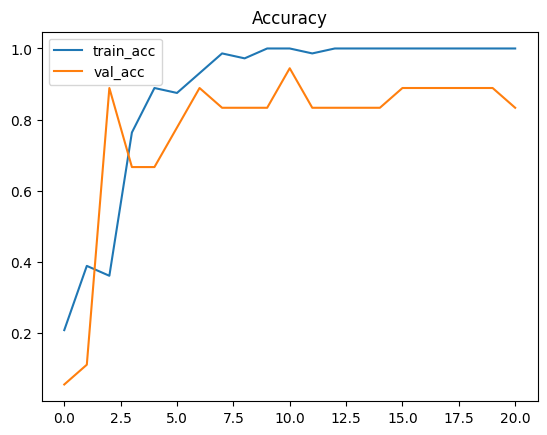

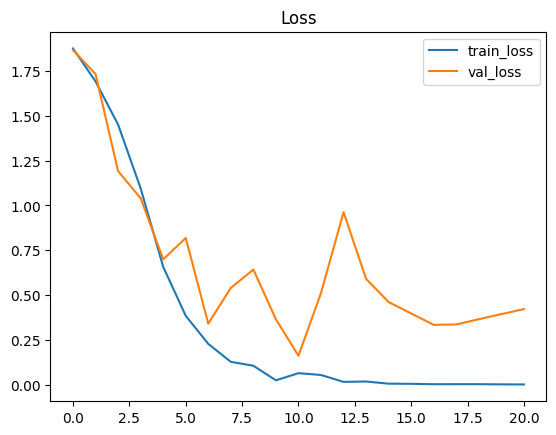

In [29]:

import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()